# Waymo Interaction Prediction Pipeline

## Installation in colab

In [1]:
!curl -sS https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3.10 get-pip.py
!python3.10 -m pip install tensorflow==2.13.0 shapely matplotlib-inline
!python3.10 -m pip install torch==2.0.1+cu118 --extra-index-url https://download.pytorch.org/whl/cu118
!python3.10 -m pip install "typing-extensions>=3.6.6,<4.6.0"
!python3.10 -m pip install matplotlib tqdm
!python3.10 -m pip install waymo-open-dataset-tf-2-12-0==1.6.7 --no-deps
!python3.12 -m pip install waymo-open-dataset-tf-2-12-0==1.6.7 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [wheel]
INFO: pip is looking at multiple versions of grpcio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.1/524.1 MB 42.3 MB/s  0:00:12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 155.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 110.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 134.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 163.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.

## Imports

In [16]:
import os, shutil, zipfile
from waymo_open_dataset.utils import womd_lidar_utils
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

## Clone the repo

In [13]:
import shutil, os

if os.path.exists("/content/WIP"):
  shutil.rmtree("/content/WIP")

!git clone https://github.com/Rohith-Kumar-S/WIP.git

Cloning into 'WIP'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 91 (delta 28), reused 72 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 66.80 KiB | 5.14 MiB/s, done.
Resolving deltas: 100% (28/28), done.


## Create directories

In [4]:
!mkdir -p /content/data/processed
!mkdir -p /content/data/training
!mkdir -p /content/data/validation

## Merge Sensor data (lidar + camera) with scenarios in the shards

In [5]:
from google.colab import auth
auth.authenticate_user()
!cd /content/WIP && python3.10 data_process.py \
  --load_path /content/data/training \
  --save_path /content/data/processed \
  --shards_path /content/data/training \
  --merger_save_path /content/data/merged/ \
  --merge_sensors

2026-04-05 03:01:01.288291: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-05 03:01:01.916733: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-05 03:01:01.918110: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 03:01:03.631637: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Cloning into 'GameFormer'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 254 (delta 10), reused 6 (delta 6), pack-reused 236 (from 1)
Receiving objects: 100% (254/254), 55.23 MiB 

## Process data

In [14]:
## Todo (also need to process sensor data to npz)
!cd /content/WIP && python3.10 data_process.py \
  --load_path /content/data/training \
  --save_path /content/data/processed \
  --shards_path /content/data/training \
  --merger_save_path /content/data/merged/ \
  --process_data

2026-04-05 03:29:33.397469: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-05 03:29:33.474411: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-05 03:29:33.475404: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 03:29:34.740259: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Cloning into 'GameFormer'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 254 (delta 10), reused 6 (delta 6), pack-reused 236 (from 1)
Receiving objects: 100% (254/254), 55.23 MiB 

## Download processed data for traning

In [6]:
!gdown "https://drive.google.com/uc?id=1bLthQs96jZ-IV1gwyO2njdahWWbz_lJd"
with zipfile.ZipFile("processed_train-20260404T145615Z-1-001.zip", "r") as zip_ref:
    zip_ref.extractall("/content/data/")


Downloading...
From (original): https://drive.google.com/uc?id=1bLthQs96jZ-IV1gwyO2njdahWWbz_lJd
From (redirected): https://drive.google.com/uc?id=1bLthQs96jZ-IV1gwyO2njdahWWbz_lJd&confirm=t&uuid=1b230e00-1d34-4bc8-b939-33773f0be0ad
To: /content/processed_train-20260404T145615Z-1-001.zip
100% 253M/253M [00:00<00:00, 253MB/s]


## Train GameFormer

In [7]:
!cd /content/WIP/ && python3.10 -m torch.distributed.launch \
  --nproc_per_node=1 \
  train.py \
  --train_set /content/data/processed_train/ \
  --valid_set /content/data/processed_train/ \
  --batch_size 128 \
  --training_epochs 10

/usr/local/lib/python3.10/dist-packages/torch/distributed/launch.py:181: FutureWarning: The module torch.distributed.launch is deprecated
and will be removed in future. Use torchrun.
Note that --use-env is set by default in torchrun.
If your script expects `--local-rank` argument to be set, please
change it to read from `os.environ['LOCAL_RANK']` instead. See 
https://pytorch.org/docs/stable/distributed.html#launch-utility for 
further instructions

  warnings.warn(
2026-04-05 03:14:58.465232: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 03:14:59.797688: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
------------- Exp1_IP -------------
Batch size: 128
Learning rate: 0.0001
Use device:

## View Sensor data

Scenario ID: 28fe360951cf98d6
  Laser 1: return1=145541 pts, return2=15459 pts
  Laser 2: return1=3578 pts, return2=8 pts
  Laser 3: return1=4237 pts, return2=25 pts
  Laser 4: return1=4275 pts, return2=35 pts
  Laser 5: return1=4490 pts, return2=71 pts

  Total points: 177719
  XYZ range: X[-72.1, 76.4] Y[-74.8, 74.9] Z[-1.6, 5.7]
  Features (range, intensity, elongation): [[5.40499988e+01 2.99999993e-02 0.00000000e+00]
 [5.40749988e+01 9.99999978e-02 0.00000000e+00]
 [4.67549990e+01 5.99999987e-02 4.99999989e-02]]

--- Camera Tokens (Frame 0) ---
  Camera 1: 256 tokens, first 10: [107, 3020, 984, 6072, 1857, 1383, 3566, 3566, 3566, 3566]
  Camera 2: 256 tokens, first 10: [12, 7646, 6322, 2448, 7517, 7755, 3135, 181, 6580, 4651]
  Camera 3: 256 tokens, first 10: [1318, 5205, 6604, 722, 2724, 5306, 281, 653, 5306, 3421]
  Camera 4: 256 tokens, first 10: [189, 6797, 7354, 4025, 697, 7646, 6264, 4519, 1291, 55]
  Camera 5: 256 tokens, first 10: [5851, 1291, 2654, 1291, 4751, 5085, 5843, 

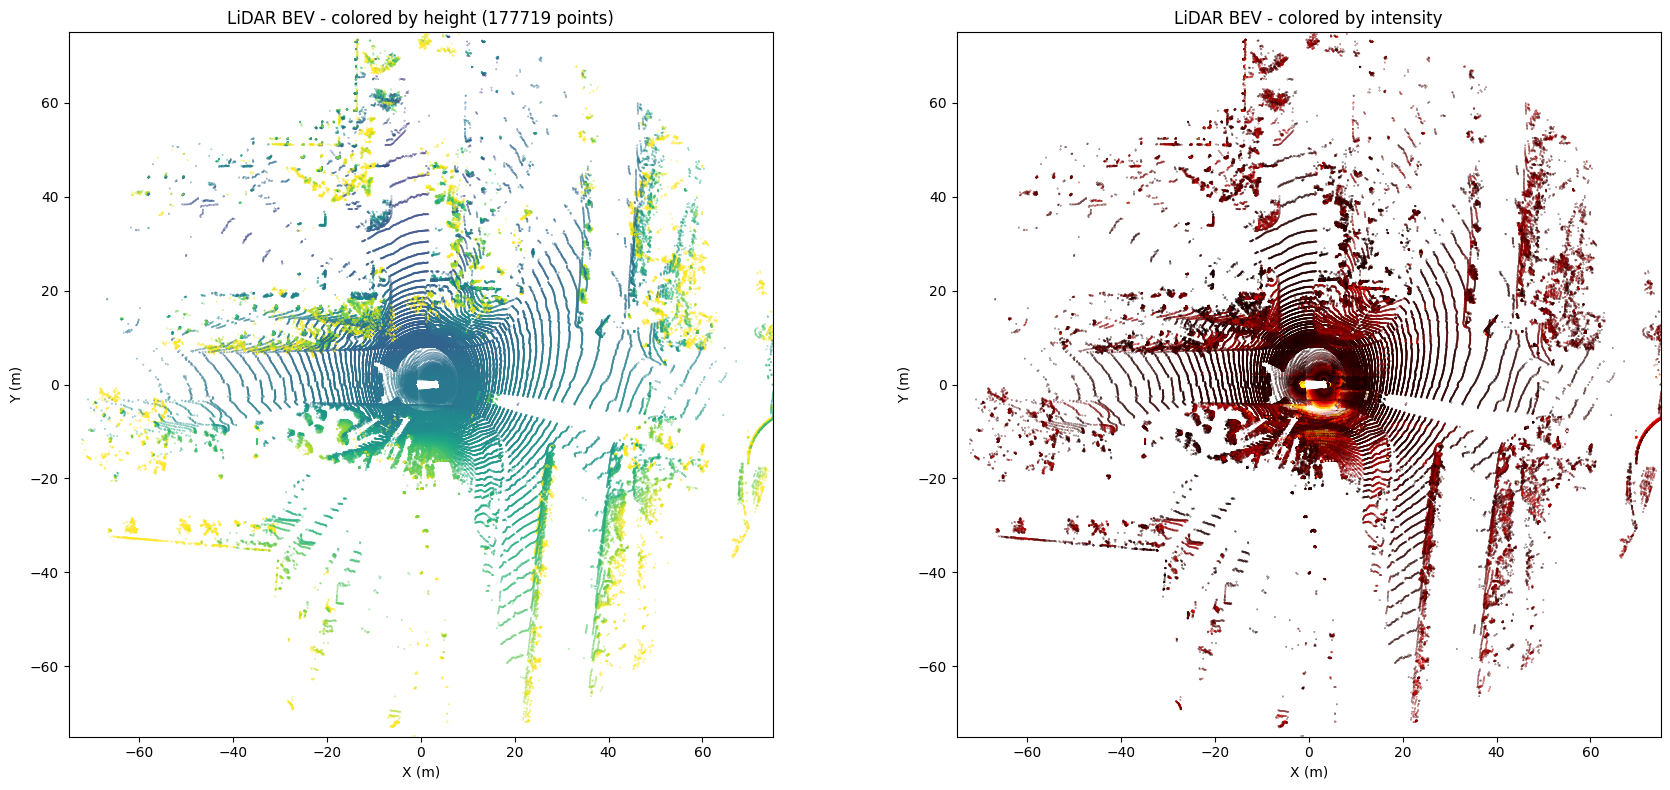

In [ ]:


dataset = tf.data.TFRecordDataset("/content/data/merged/merged_shard-00000-of-01000.tfrecord")

for data in dataset:
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())

    if len(scenario.compressed_frame_laser_data) == 0:
        continue

    print(f"Scenario ID: {scenario.scenario_id}")

    # Use first frame
    frame = scenario.compressed_frame_laser_data[0]

    # Get frame pose as 4x4 tensor
    pose = tf.constant(list(frame.pose.transform), dtype=tf.float64)
    pose = tf.reshape(pose, [4, 4])

    # Build calibration lookup by laser name
    calibs = {c.name: c for c in frame.laser_calibrations}

    all_points = []
    all_features = []

    for laser in frame.lasers:
        calib = calibs[laser.name]

        if laser.name == 1:  # TOP lidar
            xyz_ri1, feat_ri1, xyz_ri2, feat_ri2 = womd_lidar_utils.extract_top_lidar_points(
                laser, pose, calib
            )
        else:  # Side lidars
            xyz_ri1, feat_ri1, xyz_ri2, feat_ri2 = womd_lidar_utils.extract_side_lidar_points(
                laser, calib
            )

        all_points.append(xyz_ri1.numpy())
        all_points.append(xyz_ri2.numpy())
        all_features.append(feat_ri1.numpy())
        all_features.append(feat_ri2.numpy())

        print(f"Laser {laser.name}: return1={xyz_ri1.shape[0]} pts, return2={xyz_ri2.shape[0]} pts")

    # Combine all points
    pts = np.concatenate(all_points, axis=0)
    feats = np.concatenate(all_features, axis=0)
    print(f"\nTotal points: {pts.shape[0]}")
    print(f"XYZ range: X[{pts[:,0].min():.1f}, {pts[:,0].max():.1f}] Y[{pts[:,1].min():.1f}, {pts[:,1].max():.1f}] Z[{pts[:,2].min():.1f}, {pts[:,2].max():.1f}]")
    print(f"Features (range, intensity, elongation): {feats[:3]}")

    # camera tokens
    print("\n--- Camera Tokens (Frame 0) ---")
    cam_frame = scenario.frame_camera_tokens[0]
    for cam in cam_frame.camera_tokens:
        tokens = list(cam.tokens)
        print(f"Camera {cam.camera_name}: {len(tokens)} tokens, first 10: {tokens[:10]}")

    # visualize
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # BEV colored by height
    axes[0].scatter(pts[:, 0], pts[:, 1], s=0.05, c=pts[:, 2], cmap='viridis', vmin=-2, vmax=3)
    axes[0].set_xlim(-75, 75)
    axes[0].set_ylim(-75, 75)
    axes[0].set_aspect('equal')
    axes[0].set_title(f'LiDAR BEV - colored by height ({pts.shape[0]} points)')
    axes[0].set_xlabel('X (m)')
    axes[0].set_ylabel('Y (m)')

    # BEV colored by intensity
    axes[1].scatter(pts[:, 0], pts[:, 1], s=0.05, c=feats[:, 1], cmap='hot', vmin=0, vmax=1)
    axes[1].set_xlim(-75, 75)
    axes[1].set_ylim(-75, 75)
    axes[1].set_aspect('equal')
    axes[1].set_title('LiDAR BEV - colored by intensity')
    axes[1].set_xlabel('X (m)')
    axes[1].set_ylabel('Y (m)')

    plt.tight_layout()
    plt.show()

    break